In [1]:
import floodlight as floodlight
import pandas as pd
import numpy as np
import os
from floodlight import XY, Pitch
import floodlight.io.kinexon as knx
import floodlight.io.dfl as dfl
from floodlight.models.space import DiscreteVoronoiModel
import matplotlib.pyplot as plt
import time
import datetime

In [2]:
dfl_matchid =  '0028QE'
path_data = '/home/max/drive/data/positiondata1718/Daten/'
path_posdat = path_data + 'DFL_04_02_positions_raw_DFL-COM-000001_DFL-MAT-' + str(dfl_matchid) + '.xml'
path_events = path_data + 'DFL_03_02_events_raw_DFL-COM-000001_DFL-MAT-' + str(dfl_matchid) + '.xml'
path_minfo  = path_data + 'DFL_02_01_matchinformation_DFL-COM-000001_DFL-MAT-' + str(dfl_matchid) + '.xml'



In [3]:
[x for x in os.listdir(path_data) if dfl_matchid in x]

['DFL_03_02_events_raw_DFL-COM-000001_DFL-MAT-0028QE.xml',
 'DFL_02_01_matchinformation_DFL-COM-000001_DFL-MAT-0028QE.xml',
 'DFL_04_02_positions_raw_DFL-COM-000001_DFL-MAT-0028QE.xml']

In [4]:
dfl_xy, dfl_possession, dfl_ballstatus, dfl_teamsheets, dfl_pitch = dfl.read_position_data_xml(path_posdat, path_minfo, teamsheet_home=None, teamsheet_away=None)


In [5]:
dfl_possession['firstHalf'].code

array([1., 1., 1., ..., 2., 2., 2.], shape=(67513,))

In [21]:

dfl_teamsheets['Away'].teamsheet#[dfl_teamsheets['Home'].teamsheet.position == "TW"]

,player,position,team,jID,pID,tID,xID
0,L. Kübler,DRM,Sport-Club Freiburg,17,DFL-OBJ-00012Y,DFL-CLU-00000A,0
1,C. Günter,DLM,Sport-Club Freiburg,30,DFL-OBJ-00017V,DFL-CLU-00000A,1
2,T. Kleindienst,RA,Sport-Club Freiburg,34,DFL-OBJ-0001HG,DFL-CLU-00000A,2
3,M. Gulde,IVZ,Sport-Club Freiburg,5,DFL-OBJ-0000WF,DFL-CLU-00000A,3
4,A. Abrashi,DML,Sport-Club Freiburg,6,DFL-OBJ-00266D,DFL-CLU-00000A,4
5,R. Koch,DMR,Sport-Club Freiburg,25,DFL-OBJ-0025W7,DFL-CLU-00000A,5
6,J. Schuster,None,Sport-Club Freiburg,23,DFL-OBJ-000013,DFL-CLU-00000A,6
7,Ç. Söyüncü,IVR,Sport-Club Freiburg,4,DFL-OBJ-002709,DFL-CLU-00000A,7
8,P. Klandt,None,Sport-Club Freiburg,21,DFL-OBJ-0000B7,DFL-CLU-00000A,8
9,Caleb Stanko,None,Sport-Club Freiburg,33,DFL-OBJ-000268,DFL-CLU-00000A,9


In [20]:
pd.DataFrame(dfl_xy['firstHalf']['Home'].xy)

,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
0,NaN,NaN,7.07,24.98,25.02,6.86,0.57,21.20,NaN,NaN,...,NaN,NaN,20.41,-8.30,1.90,-9.78,10.00,-2.32,11.78,-25.67
1,NaN,NaN,7.13,24.97,25.05,6.87,0.55,21.20,NaN,NaN,...,NaN,NaN,20.41,-8.30,1.83,-9.81,9.98,-2.33,11.77,-25.69
2,NaN,NaN,7.17,24.96,25.07,6.89,0.55,21.18,NaN,NaN,...,NaN,NaN,20.41,-8.31,1.75,-9.85,9.96,-2.33,11.77,-25.70
3,NaN,NaN,7.21,24.95,25.11,6.92,0.55,21.18,NaN,NaN,...,NaN,NaN,20.42,-8.31,1.65,-9.87,9.95,-2.33,11.77,-25.71
4,NaN,NaN,7.25,24.95,25.13,6.93,0.55,21.18,NaN,NaN,...,NaN,NaN,20.42,-8.31,1.55,-9.91,9.93,-2.32,11.77,-25.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67508,NaN,NaN,-10.29,18.61,-2.52,7.95,-26.31,9.60,NaN,NaN,...,NaN,NaN,1.05,-8.82,-24.13,-6.49,-5.29,-5.74,-4.01,-18.96
67509,NaN,NaN,-10.25,18.57,-2.48,7.90,-26.25,9.59,NaN,NaN,...,NaN,NaN,1.11,-8.82,-24.05,-6.52,-5.22,-5.77,-3.96,-18.96
67510,NaN,NaN,-10.20,18.52,-2.43,7.86,-26.20,9.57,NaN,NaN,...,NaN,NaN,1.15,-8.83,-23.96,-6.56,-5.15,-5.81,-3.92,-18.97
67511,NaN,NaN,-10.13,18.46,-2.40,7.82,-26.14,9.57,NaN,NaN,...,NaN,NaN,1.21,-8.84,-23.89,-6.60,-5.07,-5.85,-3.87,-18.99


<Axes: >

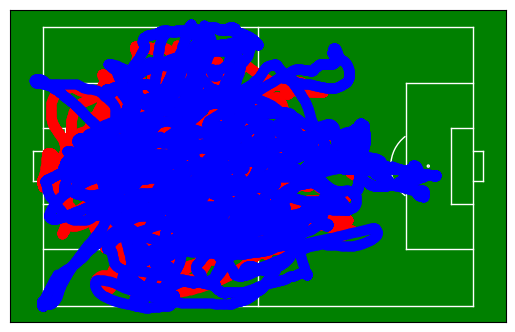

In [14]:
fig, ax = plt.subplots()
dfl_pitch.plot(ax=ax)

f_start = 1000
f_end = 5050

dfl_xy['firstHalf']['Away'].plot([np.arange(f_start,f_end)], ax=ax, color='red')
dfl_xy['firstHalf']['Home'].plot([np.arange(f_start, f_end)], ax=ax, color='blue')
#plt.scatter(xy_sample[:,0], xy_sample[:,1], color='black')

In [15]:
dfl_xy

{'firstHalf': {'Home': XY(xy=array([[   nan,    nan,   7.07, ...,  -2.32,  11.78, -25.67],
         [   nan,    nan,   7.13, ...,  -2.33,  11.77, -25.69],
         [   nan,    nan,   7.17, ...,  -2.33,  11.77, -25.7 ],
         ...,
         [   nan,    nan, -10.2 , ...,  -5.81,  -3.92, -18.97],
         [   nan,    nan, -10.13, ...,  -5.85,  -3.87, -18.99],
         [   nan,    nan, -10.09, ...,  -5.9 ,  -3.84, -19.  ]],
        shape=(67513, 36)), framerate=25, direction=None),
  'Away': XY(xy=array([[-12.44, -22.29, -15.43, ...,    nan,  -2.93,  18.08],
         [-12.43, -22.29, -15.41, ...,    nan,  -2.93,  18.08],
         [-12.42, -22.3 , -15.4 , ...,    nan,  -2.93,  18.08],
         ...,
         [-21.09, -18.66, -23.37, ...,    nan, -13.46,   7.9 ],
         [-20.99, -18.73, -23.31, ...,    nan, -13.43,   7.86],
         [-20.89, -18.79, -23.25, ...,    nan, -13.41,   7.81]],
        shape=(67513, 36)), framerate=25, direction=None),
  'Ball': XY(xy=array([[ 8.300e-01,  4.400e

In [19]:
dfl_events, a, b = dfl.read_event_data_xml(path_events, path_minfo)

/home/max/drive/coding/projects/27___deepRuns/deeprun_env/lib/python3.10/site-packages/floodlight/core/events.py:80: UserWarning: The 'gameclock' column does not match the defined value range (from floodlight.core.definitions). This may lead to unexpected behavior of methods using this column.
  warnings.warn(


In [34]:
pd.DataFrame((dfl_xy['firstHalf']['Home'].xy))

,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
0,NaN,NaN,7.07,24.98,25.02,6.86,0.57,21.20,NaN,NaN,...,NaN,NaN,20.41,-8.30,1.90,-9.78,10.00,-2.32,11.78,-25.67
1,NaN,NaN,7.13,24.97,25.05,6.87,0.55,21.20,NaN,NaN,...,NaN,NaN,20.41,-8.30,1.83,-9.81,9.98,-2.33,11.77,-25.69
2,NaN,NaN,7.17,24.96,25.07,6.89,0.55,21.18,NaN,NaN,...,NaN,NaN,20.41,-8.31,1.75,-9.85,9.96,-2.33,11.77,-25.70
3,NaN,NaN,7.21,24.95,25.11,6.92,0.55,21.18,NaN,NaN,...,NaN,NaN,20.42,-8.31,1.65,-9.87,9.95,-2.33,11.77,-25.71
4,NaN,NaN,7.25,24.95,25.13,6.93,0.55,21.18,NaN,NaN,...,NaN,NaN,20.42,-8.31,1.55,-9.91,9.93,-2.32,11.77,-25.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67508,NaN,NaN,-10.29,18.61,-2.52,7.95,-26.31,9.60,NaN,NaN,...,NaN,NaN,1.05,-8.82,-24.13,-6.49,-5.29,-5.74,-4.01,-18.96
67509,NaN,NaN,-10.25,18.57,-2.48,7.90,-26.25,9.59,NaN,NaN,...,NaN,NaN,1.11,-8.82,-24.05,-6.52,-5.22,-5.77,-3.96,-18.96
67510,NaN,NaN,-10.20,18.52,-2.43,7.86,-26.20,9.57,NaN,NaN,...,NaN,NaN,1.15,-8.83,-23.96,-6.56,-5.15,-5.81,-3.92,-18.97
67511,NaN,NaN,-10.13,18.46,-2.40,7.82,-26.14,9.57,NaN,NaN,...,NaN,NaN,1.21,-8.84,-23.89,-6.60,-5.07,-5.85,-3.87,-18.99


## Pitch Control for First Half

In [35]:
xy_home_1st = dfl_xy['firstHalf']['Home']
xy_away_1st = dfl_xy['firstHalf']['Away']

dvm = DiscreteVoronoiModel(dfl_pitch)
dvm.fit(xy_home_1st, xy_away_1st)


In [ ]:
frame = 15
#coords_home = sample_home.xy[frame,:]
#coords_away = sample_away.xy[frame,:]

ax = pitch_nordfeld.plot(color_scheme="bw")
dvm.plot(ax=ax, t=frame)
#plt.scatter(coords_home[::2], coords_home[1::2])
xy_home_firsthalf.plot(frame, ax=ax, color = "red")
xy_away_firsthalf.plot(frame, ax=ax, color = "blue")
xy_ball_firsthalf.plot(frame, ax=ax, color = "white")